In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats

import dask.dataframe as dd
from pathlib import Path
import glob

import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/activity")

In [3]:
import subsampling as ss
import activity.activity_assembly as actvt
from core import SITE_NAMES, FREQ_GROUPS

from cli import get_file_paths
import plot
import pipeline

In [4]:
import suncalc

import activity.activity_assembly as actvt

from core import DC_COLOR_MAPPINGS, SEATTLE_LATITUDE, SEATTLE_LONGITUDE

In [5]:
avail = np.arange(0, 720, 6) + 6
reset_24 = avail[np.where((24*60 % avail) == 0)[0]]
reset_24

array([  6,  12,  18,  24,  30,  36,  48,  60,  72,  90,  96, 120, 144,
       180, 240, 288, 360, 480, 720])

In [15]:
def run_for_dets(data_params, pipeline_params, file_paths):
    """
    Generate the main result of activity in a location that we use to view duty-cycling effects.
    """

    if not(pipeline_params["read_csv"]):
        if (pipeline_params['assemble_location_summary']):
            pipeline.prepare_location_sumary(data_params, pipeline_params, file_paths) 
        activity_arr = generate_activity_dets_results(data_params, file_paths)
    else:
        activity_arr = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths["dc_dets_TYPE_SITE_summary"]}.csv', index_col=0)
    
    return activity_arr

def generate_activity_dets_results(data_params, file_paths, save=False):
    """
    Generates an activity summary using the detected calls for each provided duty-cycling scheme and puts them together for comparison.
    A summary of activity is formatted as the number of detected bat calls per time interval.
    """

    activity_dets_arr = pd.DataFrame()

    for dc_tag in data_params['dc_tags']:

        location_df = ss.prepare_summary_for_plotting_with_duty_cycle_and_bins(file_paths, dc_tag, data_params['bin_size'])
        num_of_detections = actvt.get_number_of_detections_per_interval(location_df, data_params)
        dc_dets = construct_activity_arr_from_location_summary(num_of_detections, dc_tag, data_params)
        dc_dets = dc_dets.set_index("datetime_UTC")
        activity_dets_arr = pd.concat([activity_dets_arr, dc_dets], axis=1)

    if save:
        activity_dets_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths["dc_dets_TYPE_SITE_summary"]}.csv')

    return activity_dets_arr

def construct_activity_arr_from_location_summary(num_of_detections, dc_tag, data_params):
    """
    Construct an activity summary of the number of detections recorded per date and time interval.
    Will be used later to assemble an activity summary for each duty-cycling scheme to compare effects.
    """

    file_params = actvt.get_params_relevant_to_data_at_location(data_params)
    all_processed_filepaths = file_params['good_audio_files']
    all_processed_datetimes = pd.to_datetime(all_processed_filepaths, format="%Y%m%d_%H%M%S", exact=False)
    col_name = f"num_dets ({dc_tag})"
    incomplete_activity_arr = pd.DataFrame(num_of_detections.values, index=num_of_detections.index, columns=[col_name])
    expected_dt_bins = pd.date_range(all_processed_datetimes[0], all_processed_datetimes[-1], freq=f'{data_params["bin_size"]}T')
    activity_arr = incomplete_activity_arr.reindex(index=expected_dt_bins, fill_value=0).resample(f"{data_params['bin_size']}T").first()
    activity_arr = activity_arr.between_time(data_params['recording_start'], data_params['recording_end'], inclusive='left')

    return pd.DataFrame(list(zip(activity_arr.index, activity_arr[col_name].values)), columns=["datetime_UTC", col_name])

In [7]:
def plot_activity_grid_for_dets(activity_arr, data_params, pipeline_params, file_paths):
    """
    Plots an activity grid generated from an activity summary for a specific duty-cycling scheme.
    The activity summary here is of the number of detections observed per date and time interval.
    """
    activity_df = actvt.construct_activity_grid_for_number_of_dets(activity_arr, data_params["cur_dc_tag"])

    activity_times = pd.DatetimeIndex(activity_df.index).tz_localize('UTC')
    activity_dates = pd.DatetimeIndex(activity_df.columns).strftime("%m/%d/%y")
    ylabel = 'UTC'
    if pipeline_params["show_PST"]:
        activity_times = activity_times.tz_convert(tz='US/Pacific')
        ylabel = 'PST'
    activity_times = activity_times.strftime("%H:%M")
    plot_times = [''] * len(activity_times)
    plot_times[2::4] = activity_times[2::4]
    plot_times[np.where(plot_times=='00:00')[0]] = 'Midnight'
    plot_dates = [''] * len(activity_dates)
    plot_dates[::7] = activity_dates[::7]

    dates_for_sunrise_sunset = pd.to_datetime(activity_df.columns.values, format='%m/%d/%y')
    activity_lat = [SEATTLE_LATITUDE]*len(dates_for_sunrise_sunset)
    activity_lon = [SEATTLE_LONGITUDE]*len(dates_for_sunrise_sunset)
    sunrise_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunrise_end'])
    sunset_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunset_start'])
    sunrise_seconds_from_midnight = sunrise_time.hour * 3600 + sunrise_time.minute*60 + sunrise_time.second
    sunset_seconds_from_midnight = sunset_time.hour * 3600 + sunset_time.minute*60 + sunset_time.second

    on = int(data_params['cur_dc_tag'].split('of')[0])
    total = int(data_params['cur_dc_tag'].split('of')[1])
    bin_size = int(data_params['bin_size'])
    recover_ratio = min(total, bin_size) / min(on, bin_size)

    if total-on >= bin_size:
        activity_df = activity_df.replace(np.NaN, -1).replace(0, np.NaN)
        activity_df = activity_df.ffill(limit=(min((14*60)-on, total-on)//bin_size))
        activity_df = activity_df.replace(np.NaN, 0).replace(-1, np.NaN)

    masked_array_for_nodets = np.ma.masked_where(activity_df.values==np.NaN, activity_df.values)
    cmap = plt.get_cmap('viridis')
    cmap.set_bad(color='red')
    plt.rcParams.update({'font.size': (0.8*len(activity_dates) + 0.8*len(activity_times))})
    plt.figure(figsize=(1*len(activity_dates), 1*len(activity_times)))
    title = f"Activity (# of low-frequency calls) from {data_params['site_name']}"
    # plt.title(title, fontsize=0.8*len(activity_dates) + 1.4*len(activity_times))
    plt.imshow(1+(recover_ratio*masked_array_for_nodets), cmap=cmap, norm=colors.LogNorm(vmin=1, vmax=10e3))
    plt.plot(np.arange(0, len(plot_dates)), ((sunset_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
            color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunset')
    plt.axhline(y=np.where(activity_times=='00:00')[0]-0.5, linewidth=0.5*len(activity_times), linestyle='dashed', color='white', label='Midnight 0:00 PST')
    plt.plot(np.arange(0, len(plot_dates)), ((sunrise_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
            color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunrise')
    plt.yticks(np.arange(0, len(activity_df.index))-0.5, plot_times, rotation=30)
    plt.xticks(np.arange(0, len(activity_df.columns))-0.5, plot_dates, rotation=30)
    plt.ylabel(f'{ylabel} Time (HH:MM)')
    plt.xlabel('Date (MM/DD/YY)')
    plt.grid(which='both', linewidth=2)
    # plt.legend(loc=3, ncol=3, fontsize=0.7*len(activity_dates) + 1*len(activity_times))
    plt.colorbar()
    plt.tight_layout()
    if pipeline_params["save_activity_grid"]:
        plt.savefig(f'{file_paths["activity_grid_folder"]}/{file_paths["activity_dets_grid_figname"]}.png', bbox_inches='tight')
        plt.close()
    if pipeline_params["show_plots"]:
        plt.show()

In [8]:
def plot_site_activity_grid_manuscript(activity_df, data_params, pipeline_params):
    activity_times = pd.DatetimeIndex(activity_df.index).tz_localize('UTC')
    activity_dates = pd.DatetimeIndex(activity_df.columns).strftime("%m/%d/%y")
    ylabel = 'UTC'
    if pipeline_params["show_PST"]:
        activity_times = activity_times.tz_convert(tz='US/Pacific')
        ylabel = 'PST'
    activity_times = activity_times.strftime("%H:%M")
    plot_times = [''] * len(activity_times)
    plot_times[2::4] = activity_times[2::4]
    plot_dates = [''] * len(activity_dates)
    plot_dates[::7] = activity_dates[::7]

    dates_for_sunrise_sunset = pd.to_datetime(activity_df.columns.values, format='%m/%d/%y')
    activity_lat = [SEATTLE_LATITUDE]*len(dates_for_sunrise_sunset)
    activity_lon = [SEATTLE_LONGITUDE]*len(dates_for_sunrise_sunset)
    sunrise_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunrise_end'])
    sunset_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunset_start'])
    sunrise_seconds_from_midnight = sunrise_time.hour * 3600 + sunrise_time.minute*60 + sunrise_time.second
    sunset_seconds_from_midnight = sunset_time.hour * 3600 + sunset_time.minute*60 + sunset_time.second

    on = int(data_params['cur_dc_tag'].split('of')[0])
    total = int(data_params['cur_dc_tag'].split('of')[1])
    bin_size = int(data_params['bin_size'])
    recover_ratio = min(total, bin_size) / min(on, bin_size)

    masked_array_for_nodets = np.ma.masked_where(activity_df.values==np.NaN, activity_df.values)
    cmap = plt.get_cmap('viridis')
    cmap.set_bad(color='red')
    title = f"Activity (# of low-frequency calls) from {data_params['site_name']}"
    plt.imshow(1+(masked_array_for_nodets), cmap=cmap, norm=colors.LogNorm(vmin=1, vmax=10e3))
    plt.plot(np.arange(0, len(plot_dates)), ((sunset_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
            color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunset')
    plt.axhline(y=np.where(activity_times=='00:00')[0]-0.5, linewidth=0.5*len(activity_times), linestyle='dashed', color='white', label='Midnight 0:00 PST')
    plt.plot(np.arange(0, len(plot_dates)), ((sunrise_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
            color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunrise')
    plt.yticks(np.arange(0, len(activity_df.index))-0.5, plot_times, rotation=30)
    plt.xticks(np.arange(0, len(activity_df.columns))-0.5, plot_dates, rotation=30)
    plt.ylabel(f'{ylabel} Time (HH:MM)')
    plt.xlabel('Date (MM/DD/YY)')
    plt.grid(which='both', linewidth=6, alpha=0.4)
    plt.colorbar()

In [9]:
cycle_lengths = [10]
percent_ons = [1/2]
specific_dc_tag = "30of30"

data_params = dict()
data_params["year"] = '2022'
data_params["cycle_lengths"] = cycle_lengths
data_params["percent_ons"] = percent_ons
dc_tags = ss.get_list_of_dc_tags(data_params["cycle_lengths"], data_params["percent_ons"])
data_params["dc_tags"] = dc_tags
data_params["cur_dc_tag"] = specific_dc_tag
data_params['detector_tag'] = 'bd2'
data_params['bin_size'] = '30'
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['assembly_type'] = 'kmeans'

pipeline_params = dict()
pipeline_params['assemble_location_summary'] = False
pipeline_params["read_csv"] = False
pipeline_params["save_activity_grid"] = False
pipeline_params["save_presence_grid"] = False
pipeline_params["save_dc_night_comparisons"] = False
pipeline_params["save_activity_dc_comparisons"] = True
pipeline_params["save_presence_dc_comparisons"] = True
pipeline_params["show_plots"] = True
pipeline_params["show_PST"] = True

In [10]:
site_key = 'Carp'
type_key = ''
data_params["site_name"] = SITE_NAMES[site_key]
data_params["site_tag"] = site_key
data_params["type_tag"] = type_key

file_paths = get_file_paths(data_params)
activity_dets_arr = pipeline.run_for_dets(data_params, pipeline_params, file_paths)
activity_df1 = actvt.construct_activity_grid_for_number_of_dets(activity_dets_arr, data_params["cur_dc_tag"])

activity_times = pd.DatetimeIndex(activity_df1.index).tz_localize('UTC')
activity_dates = pd.DatetimeIndex(activity_df1.columns).strftime("%m/%d/%y")
activity_times = activity_times.tz_convert(tz='US/Pacific')
ylabel = 'PST'
activity_times = activity_times.strftime("%H:%M")
plot_times = [''] * len(activity_times)
plot_times[::4] = activity_times[::4]
plot_times += ['08:00']
plot_dates = [''] * len(activity_dates)
plot_dates[::7] = activity_dates[::7]
dates_for_sunrise_sunset = pd.to_datetime(activity_df1.columns.values, format='%m/%d/%y')
activity_lat = [SEATTLE_LATITUDE]*len(dates_for_sunrise_sunset)
activity_lon = [SEATTLE_LONGITUDE]*len(dates_for_sunrise_sunset)
sunrise_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunrise_end'])
sunset_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunset_start'])
sunrise_seconds_from_midnight = sunrise_time.hour * 3600 + sunrise_time.minute*60 + sunrise_time.second
sunset_seconds_from_midnight = sunset_time.hour * 3600 + sunset_time.minute*60 + sunset_time.second


site_key = 'Telephone'
type_key = ''
data_params["site_name"] = SITE_NAMES[site_key]
data_params["site_tag"] = site_key
data_params["type_tag"] = type_key

file_paths = get_file_paths(data_params)
activity_dets_arr = pipeline.run_for_dets(data_params, pipeline_params, file_paths)
activity_df2 = actvt.construct_activity_grid_for_number_of_dets(activity_dets_arr, data_params["cur_dc_tag"])
activity_df3 = activity_df2.reindex(columns=activity_df1.columns, fill_value=np.NaN)

cmap = plt.get_cmap('viridis')
norm = colors.LogNorm(vmin=1, vmax=10e3)
cmap.set_bad(color='darkred')

In [11]:
plt.rcParams.update({'font.size': (0.8*len(activity_dates) + 0.8*len(activity_times))})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(1*len(activity_dates), 2*len(activity_times)), sharex=True, sharey=True)
masked_array_for_nodets = np.ma.masked_where(activity_df1.values==np.NaN, activity_df1.values)
im1 = ax1.imshow(1+(masked_array_for_nodets), cmap=cmap, norm=norm)
ax1.plot(np.arange(0, len(plot_dates)), ((sunset_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
        color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunset')
ax1.axhline(y=np.where(activity_times=='00:00')[0]-0.5, linewidth=0.5*len(activity_times), linestyle='dashed', color='white', label='Midnight 0:00 PST')
ax1.plot(np.arange(0, len(plot_dates)), ((sunrise_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
        color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunrise')
ax1.grid(which='both', linewidth=6, alpha=0.4)
ax1.set_ylabel(f'Time (HH:MM, {ylabel})')
ax1.set_yticks(np.arange(0, len(plot_times))-0.5)
ax1.set_yticklabels(plot_times, ha='right')

masked_array_for_nodets = np.ma.masked_where(activity_df3.values==np.NaN, activity_df3.values)
im2 = ax2.imshow(1+masked_array_for_nodets, cmap=cmap, norm=norm)
ax2.plot(np.arange(0, len(plot_dates)), ((sunset_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
        color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunset')
ax2.axhline(y=np.where(activity_times=='00:00')[0]-0.5, linewidth=0.5*len(activity_times), linestyle='dashed', color='white', label='Midnight 0:00 PST')
ax2.plot(np.arange(0, len(plot_dates)), ((sunrise_seconds_from_midnight / (30*60)) % len(plot_times)) - 0.5, 
        color='white', linewidth=0.5*len(activity_times), linestyle='dashed', label=f'Time of Sunrise')
ax2.set_ylabel(f'Time (HH:MM, {ylabel})')
ax2.set_xlabel('Date (MM/DD/YY)')
ax2.grid(which='both', linewidth=6, alpha=0.4)
ax2.set_xticks(np.arange(0, len(activity_df1.columns))-0.5)
ax2.set_xticklabels(plot_dates, rotation=30)
ax2.set_yticks(np.arange(0, len(plot_times)) - 0.5)
ax2.set_yticklabels(plot_times, ha='right')

fig.tight_layout()

pos1 = ax1.get_position(original=False)
pos2 = ax2.get_position(original=False)
colorbar_ax = fig.add_axes([pos2.x1 + 0.02, pos2.y0, 0.02, (pos1.y1 - pos2.y0)])
cbar = fig.colorbar(im1, cax=colorbar_ax, orientation='vertical')
fig.text(x=pos1.x1 - 0.04, y=pos1.y1 + 0.04, s='Number of calls', fontweight='bold',
         fontsize=(1.2*len(activity_dates) + 1.2*len(activity_times)))

plt.show()

In [12]:
cycle_lengths = [10]
percent_ons = [1/2]
specific_dc_tag = "30of30"

data_params = dict()
data_params["year"] = '2022'
data_params["cycle_lengths"] = cycle_lengths
data_params["percent_ons"] = percent_ons
dc_tags = ss.get_list_of_dc_tags(data_params["cycle_lengths"], data_params["percent_ons"])
data_params["dc_tags"] = dc_tags
data_params["cur_dc_tag"] = specific_dc_tag
data_params['detector_tag'] = 'bd2'
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['assembly_type'] = 'kmeans'

pipeline_params = dict()
pipeline_params['assemble_location_summary'] = False
pipeline_params["read_csv"] = False
pipeline_params["save_activity_grid"] = False
pipeline_params["save_presence_grid"] = False
pipeline_params["save_dc_night_comparisons"] = False
pipeline_params["save_activity_dc_comparisons"] = True
pipeline_params["save_presence_dc_comparisons"] = True
pipeline_params["show_plots"] = True
pipeline_params["show_PST"] = True

In [16]:
site_key = 'Foliage'
type_key = ''
data_params['bin_size'] = '5'
data_params["site_name"] = SITE_NAMES[site_key]
data_params["site_tag"] = site_key
data_params["type_tag"] = type_key

file_paths = get_file_paths(data_params)
activity_dets_arr = run_for_dets(data_params, pipeline_params, file_paths)
activity_df1 = actvt.construct_activity_grid_for_number_of_dets(activity_dets_arr, data_params["cur_dc_tag"])

activity_times = pd.DatetimeIndex(activity_df1.index).tz_localize('UTC')
activity_dates = pd.DatetimeIndex(activity_df1.columns).strftime("%m/%d/%y")
activity_times = activity_times.tz_convert(tz='US/Pacific')
ylabel = 'PST'
activity_times = activity_times.strftime("%H:%M")
plot_times = [''] * len(activity_times)
plot_times[::4] = activity_times[::4]
plot_times += ['08:00']
plot_dates = [''] * len(activity_dates)
plot_dates[::7] = activity_dates[::7]
dates_for_sunrise_sunset = pd.to_datetime(activity_df1.columns.values, format='%m/%d/%y')
activity_lat = [SEATTLE_LATITUDE]*len(dates_for_sunrise_sunset)
activity_lon = [SEATTLE_LONGITUDE]*len(dates_for_sunrise_sunset)
sunrise_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunrise_end'])
sunset_time = pd.DatetimeIndex(suncalc.get_times(dates_for_sunrise_sunset, activity_lon, activity_lat)['sunset_start'])
sunrise_seconds_from_midnight = sunrise_time.hour * 3600 + sunrise_time.minute*60 + sunrise_time.second
sunset_seconds_from_midnight = sunset_time.hour * 3600 + sunset_time.minute*60 + sunset_time.second

site_key = 'Central'
type_key = ''
data_params["site_name"] = SITE_NAMES[site_key]
data_params["site_tag"] = site_key
data_params["type_tag"] = type_key

file_paths = get_file_paths(data_params)
activity_dets_arr = run_for_dets(data_params, pipeline_params, file_paths)
activity_df2 = actvt.construct_activity_grid_for_number_of_dets(activity_dets_arr, data_params["cur_dc_tag"])
activity_df2 = activity_df2.reindex(columns=activity_df1.columns, fill_value=np.NaN)

site_key = 'Carp'
type_key = ''
data_params["site_name"] = SITE_NAMES[site_key]
data_params["site_tag"] = site_key
data_params["type_tag"] = type_key

file_paths = get_file_paths(data_params)
activity_dets_arr = run_for_dets(data_params, pipeline_params, file_paths)
activity_df3 = actvt.construct_activity_grid_for_number_of_dets(activity_dets_arr, data_params["cur_dc_tag"])
activity_df3 = activity_df3.reindex(columns=activity_df1.columns, fill_value=np.NaN)

site_key = 'Telephone'
type_key = ''
data_params["site_name"] = SITE_NAMES[site_key]
data_params["site_tag"] = site_key
data_params["type_tag"] = type_key

file_paths = get_file_paths(data_params)
activity_dets_arr = run_for_dets(data_params, pipeline_params, file_paths)
activity_df4 = actvt.construct_activity_grid_for_number_of_dets(activity_dets_arr, data_params["cur_dc_tag"])
activity_df4 = activity_df4.reindex(columns=activity_df1.columns, fill_value=np.NaN)

cmap = plt.get_cmap('viridis')
norm = colors.LogNorm(vmin=1, vmax=10e3)
cmap.set_bad(color='darkred')

In [18]:
location_df = ss.prepare_summary_for_plotting_with_duty_cycle_and_bins(file_paths, '30of30', data_params['bin_size'])
num_of_detections = actvt.get_number_of_detections_per_interval(location_df, data_params)
num_of_detections

ref_time
2022-07-23 04:25:00     53
2022-07-23 04:30:00    156
2022-07-23 04:35:00    399
2022-07-23 04:40:00    123
2022-07-23 04:45:00    234
                      ... 
2022-10-17 13:30:00    115
2022-10-17 13:35:00    220
2022-10-17 13:40:00    244
2022-10-17 13:45:00     53
2022-10-17 13:50:00      2
Freq: 5T, Name: ref_time, Length: 24882, dtype: int64

In [19]:
# dc_dets = actvt.construct_activity_arr_from_location_summary(num_of_detections, '30of30', data_params)
# dc_dets[700:]
file_params = actvt.get_params_relevant_to_data_at_location(data_params)
all_processed_filepaths = file_params['good_audio_files']
all_processed_datetimes = pd.to_datetime(all_processed_filepaths, format="%Y%m%d_%H%M%S", exact=False)
col_name = f"num_dets (30of30)"
incomplete_activity_arr = pd.DataFrame(num_of_detections.values, index=num_of_detections.index, columns=[col_name])
incomplete_activity_arr

,num_dets (30of30)
ref_time,
2022-07-23 04:25:00,53
2022-07-23 04:30:00,156
2022-07-23 04:35:00,399
2022-07-23 04:40:00,123
2022-07-23 04:45:00,234
...,...
2022-10-17 13:30:00,115
2022-10-17 13:35:00,220
2022-10-17 13:40:00,244


In [ ]:
expected_dt_bins = pd.date_range(all_processed_datetimes[0], all_processed_datetimes[-1], freq=f'{data_params['bin_size']}T')

In [61]:
activity_arr = incomplete_activity_arr.reindex(index=expected_dt_bins, fill_value=0).resample(f"{data_params['bin_size']}T").first()
activity_arr = activity_arr.between_time(data_params['recording_start'], data_params['recording_end'], inclusive='left')

In [62]:
pd.DataFrame(list(zip(activity_arr.index, activity_arr[col_name].values)), columns=["datetime_UTC", col_name])

,datetime_UTC,num_dets (30of30)
0,2022-07-23 00:00:00,0
1,2022-07-23 00:10:00,0
2,2022-07-23 00:20:00,0
3,2022-07-23 00:30:00,0
4,2022-07-23 00:40:00,0
...,...,...
8345,2022-10-17 14:50:00,0
8346,2022-10-17 15:00:00,0
8347,2022-10-17 15:10:00,0
8348,2022-10-17 15:20:00,0


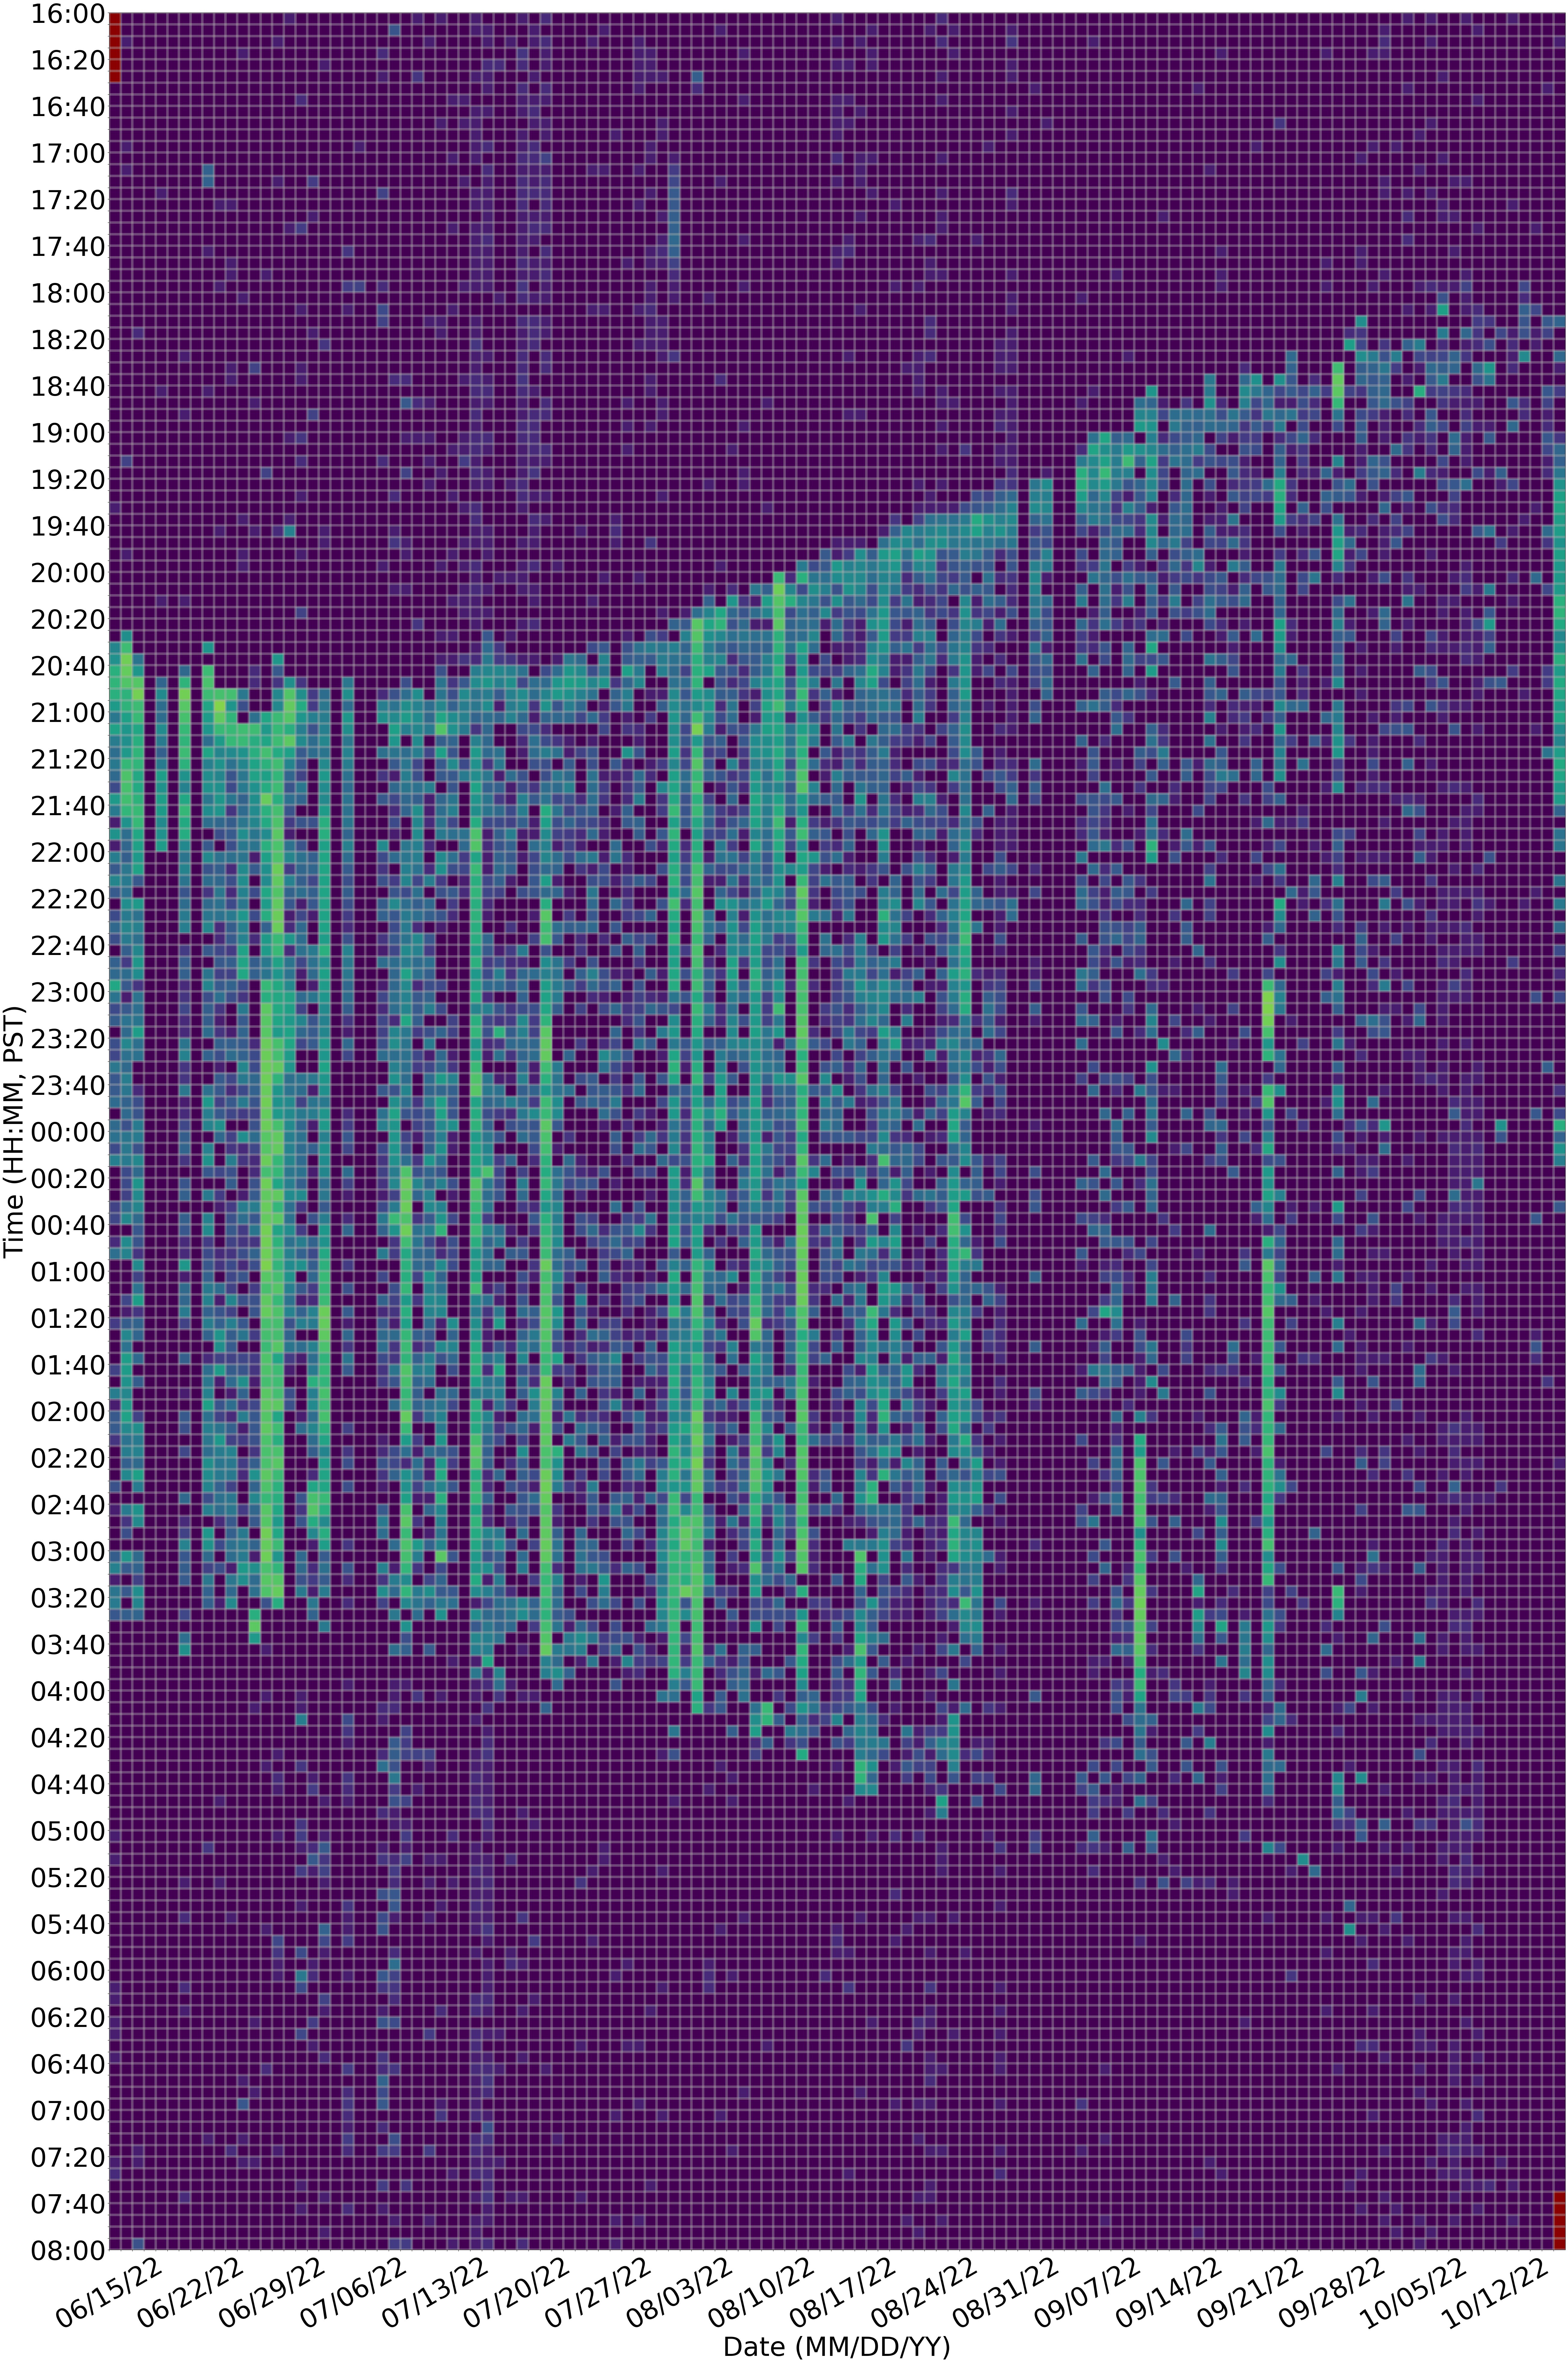

In [17]:
plt.rcParams.update({'font.size': (0.2*len(activity_dates) + 0.2*len(activity_times))})
fig, (ax1) = plt.subplots(1, 1, figsize=(0.5*len(activity_dates), 0.6*len(activity_times)), sharex=True, sharey=True)

masked_array_for_nodets = np.ma.masked_where(activity_df1.values==np.NaN, activity_df1.values)
im1 = ax1.imshow(1+(masked_array_for_nodets), cmap=cmap, norm=norm)
ax1.grid(which='both', linewidth=6, alpha=0.4)
ax1.set_ylabel(f'Time (HH:MM, {ylabel})')
ax1.set_xlabel('Date (MM/DD/YY)')
ax1.set_yticks(np.arange(0, len(plot_times))-0.5)
ax1.set_yticklabels(plot_times, ha='right')
ax1.set_xticks(np.arange(0, len(activity_df1.columns))-0.5)
ax1.set_xticklabels(plot_dates, rotation=30)

plt.show()

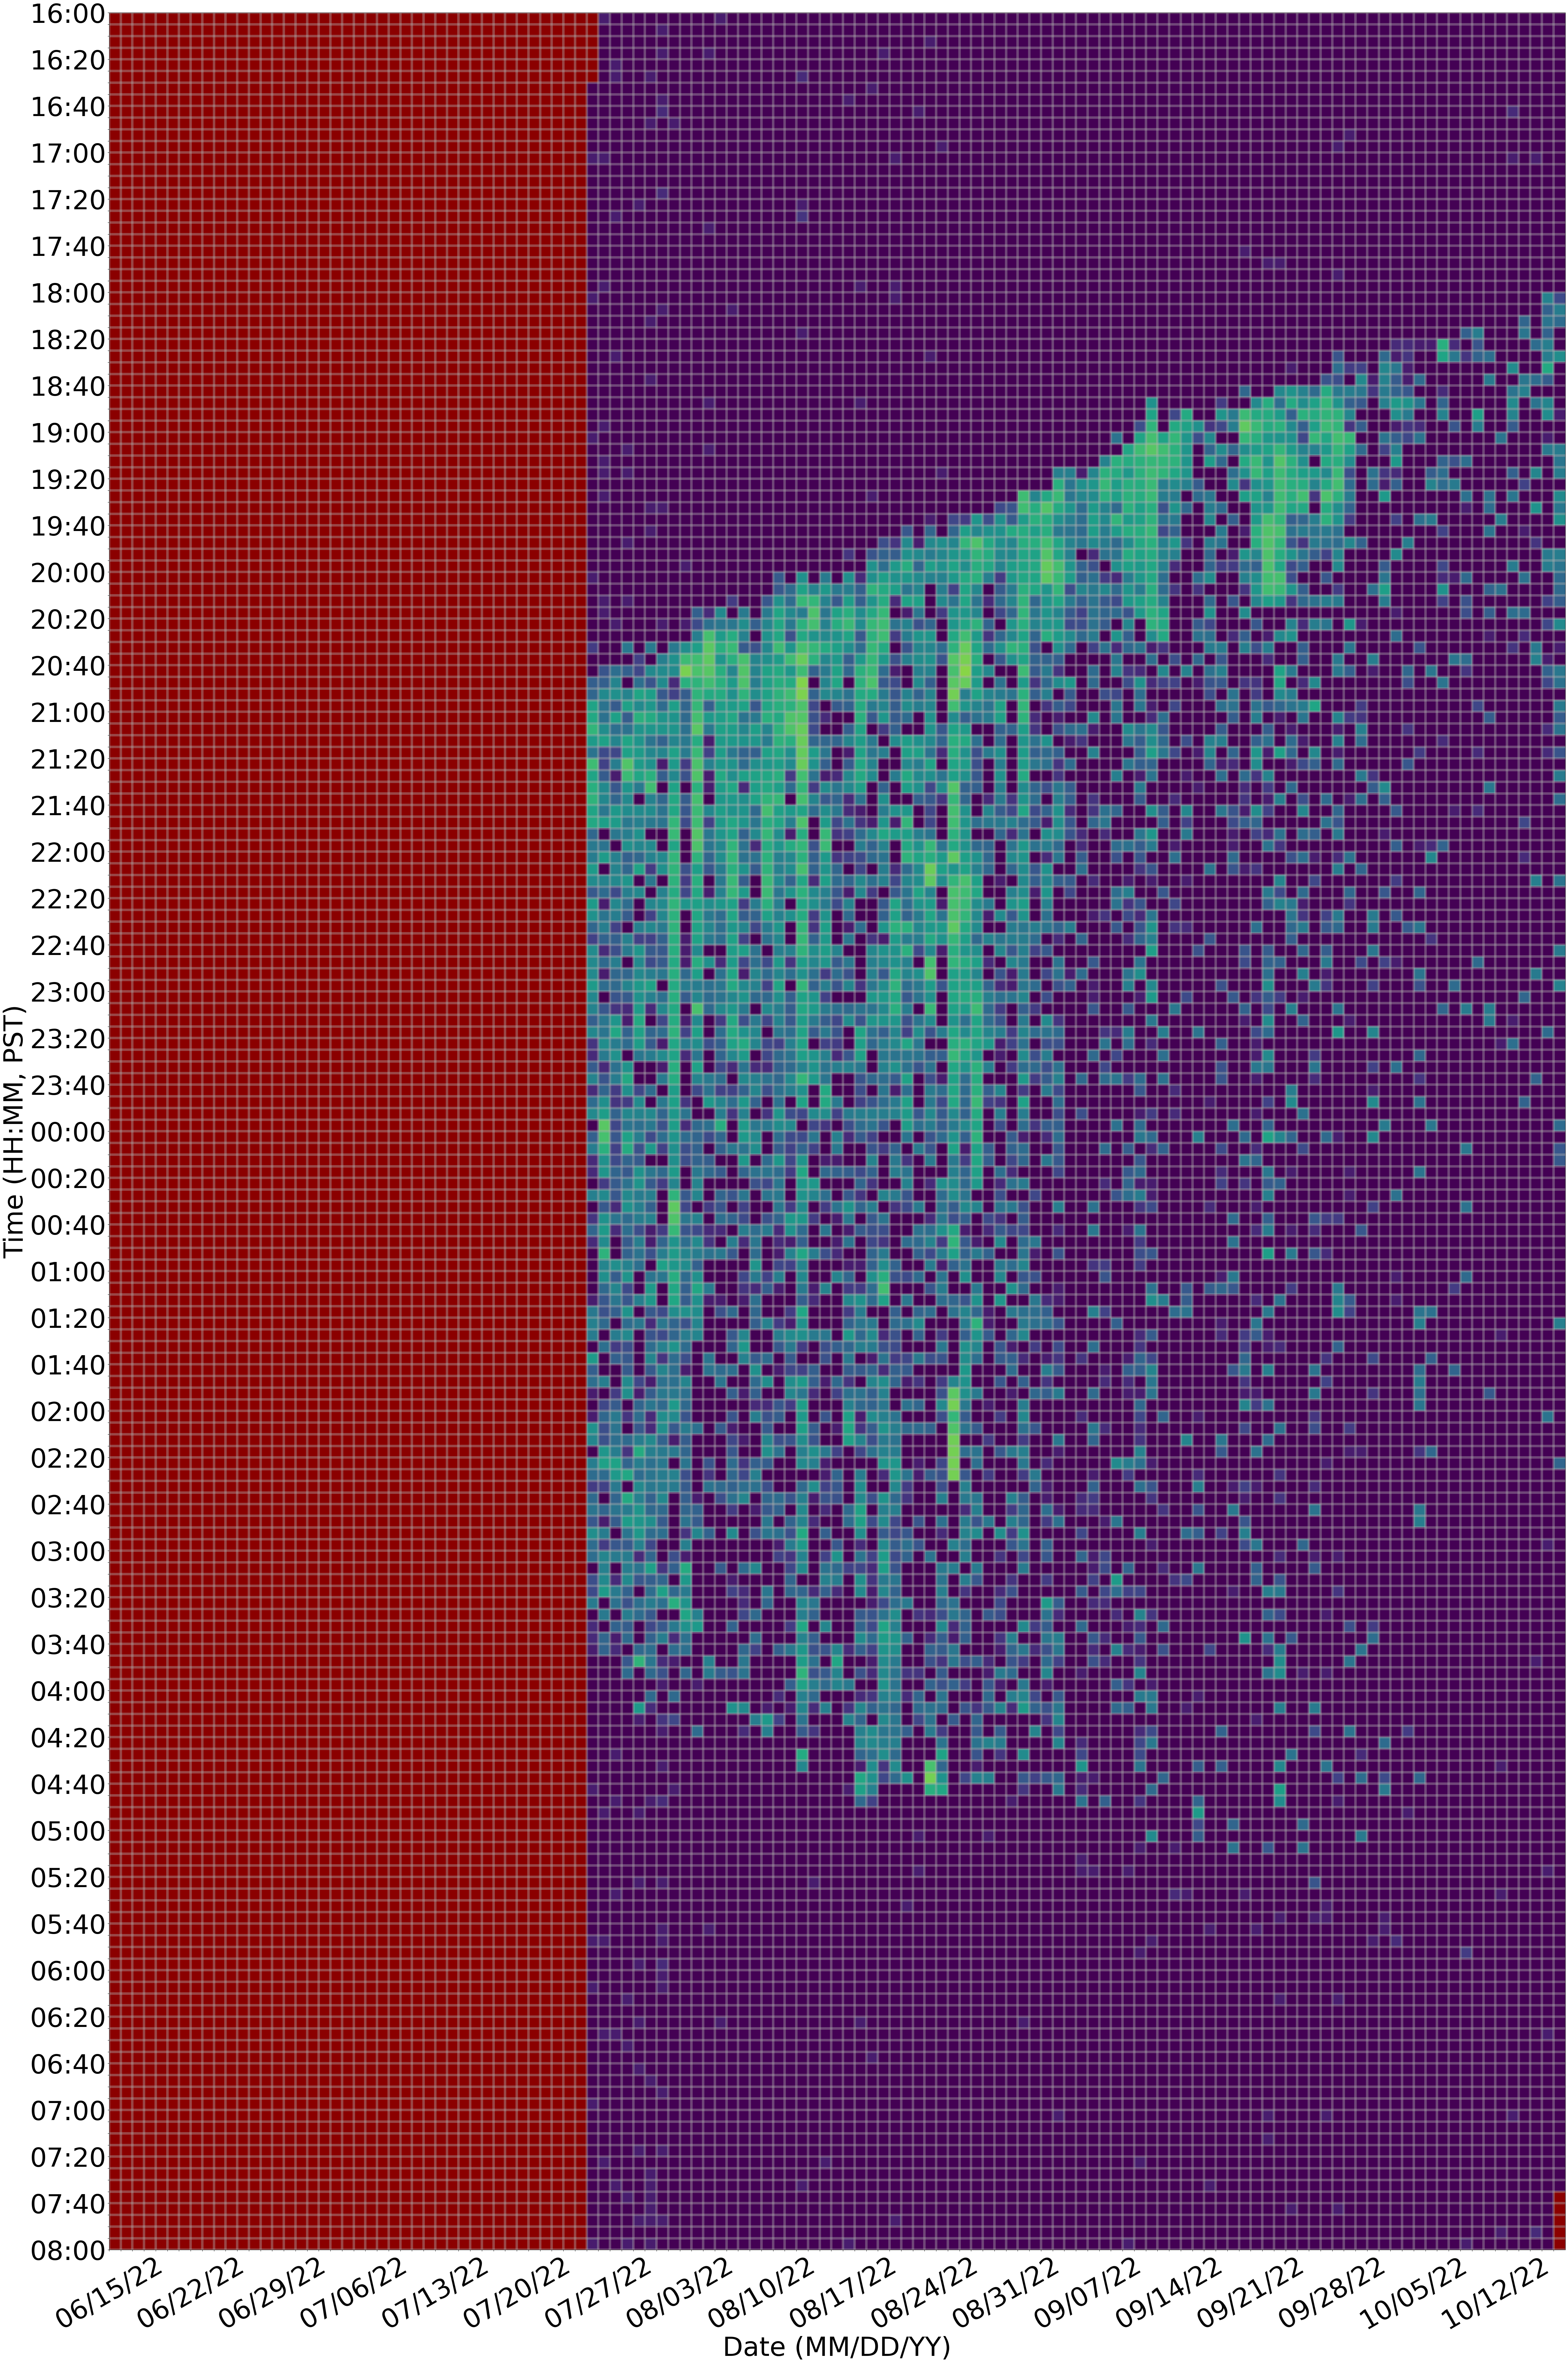

In [41]:
plt.rcParams.update({'font.size': (0.2*len(activity_dates) + 0.2*len(activity_times))})
fig, (ax1) = plt.subplots(1, 1, figsize=(0.5*len(activity_dates), 0.6*len(activity_times)), sharex=True, sharey=True)

masked_array_for_nodets = np.ma.masked_where(activity_df2.values==np.NaN, activity_df2.values)
im1 = ax1.imshow(1+(masked_array_for_nodets), cmap=cmap, norm=norm)
ax1.grid(which='both', linewidth=6, alpha=0.4)
ax1.set_ylabel(f'Time (HH:MM, {ylabel})')
ax1.set_xlabel('Date (MM/DD/YY)')
ax1.set_yticks(np.arange(0, len(plot_times))-0.5)
ax1.set_yticklabels(plot_times, ha='right')
ax1.set_xticks(np.arange(0, len(activity_df1.columns))-0.5)
ax1.set_xticklabels(plot_dates, rotation=30)

plt.show()

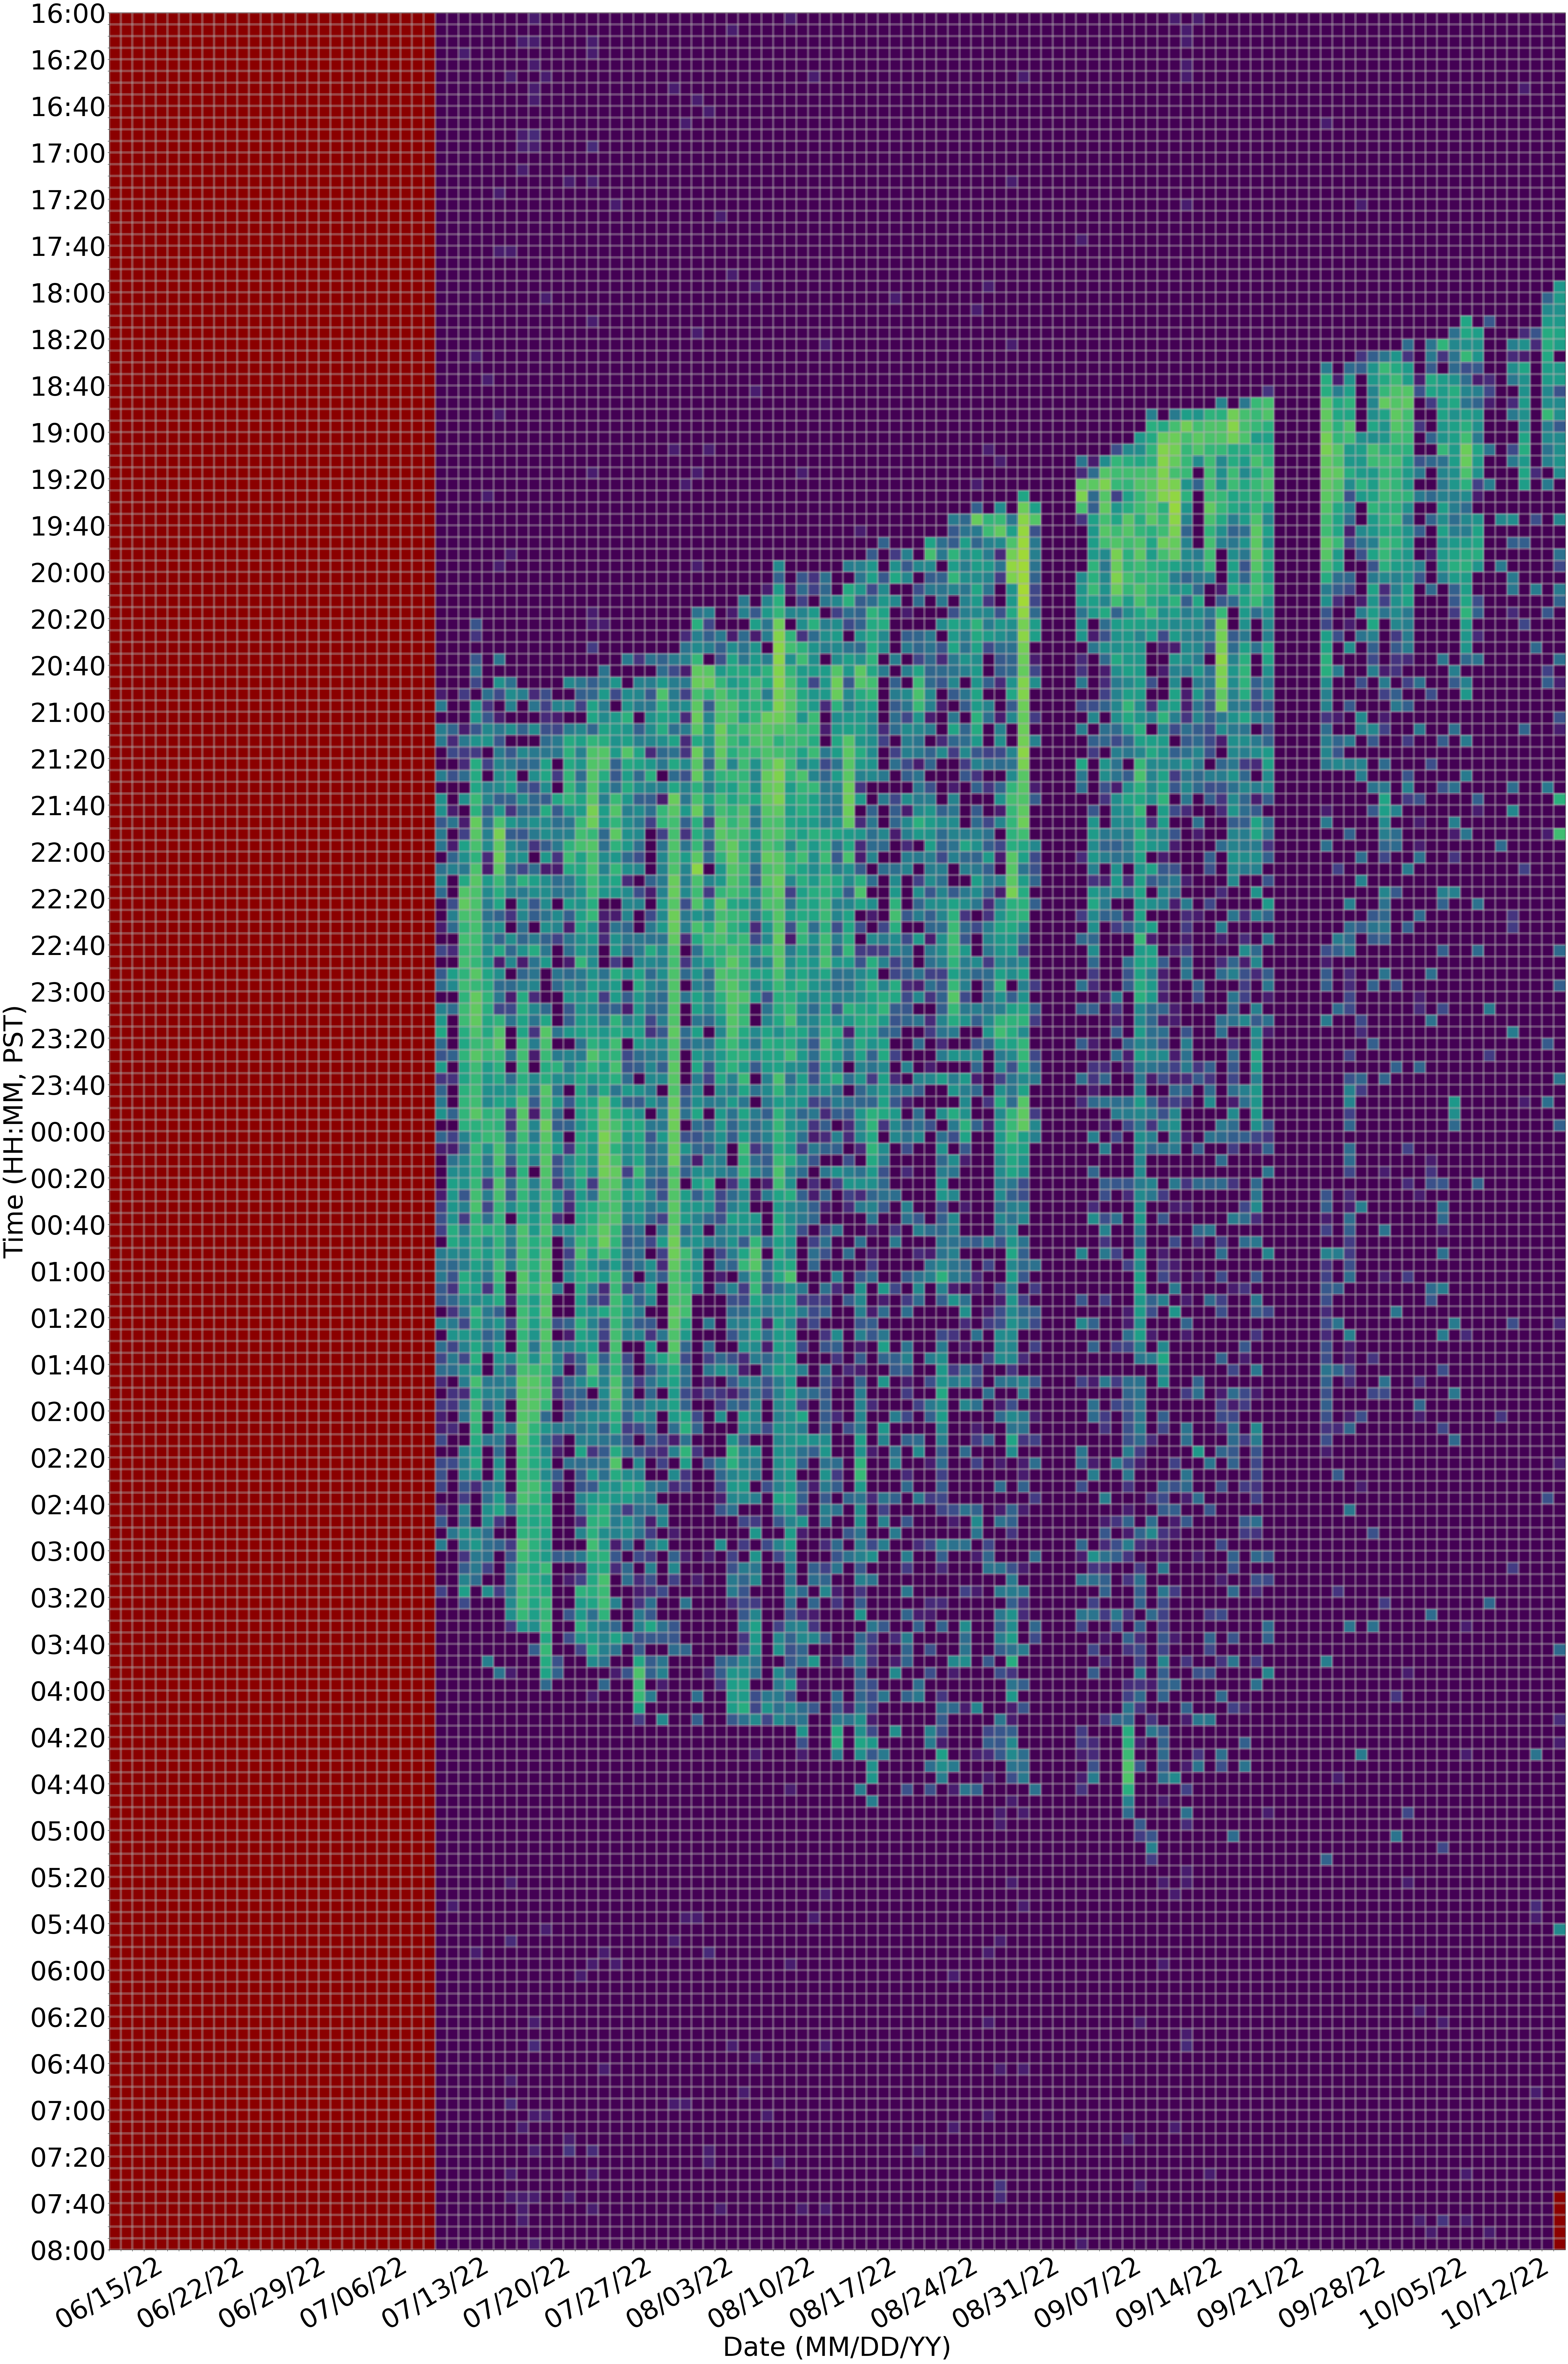

In [42]:
plt.rcParams.update({'font.size': (0.2*len(activity_dates) + 0.2*len(activity_times))})
fig, (ax1) = plt.subplots(1, 1, figsize=(0.5*len(activity_dates), 0.6*len(activity_times)), sharex=True, sharey=True)

masked_array_for_nodets = np.ma.masked_where(activity_df3.values==np.NaN, activity_df3.values)
im1 = ax1.imshow(1+(masked_array_for_nodets), cmap=cmap, norm=norm)
ax1.grid(which='both', linewidth=6, alpha=0.4)
ax1.set_ylabel(f'Time (HH:MM, {ylabel})')
ax1.set_xlabel('Date (MM/DD/YY)')
ax1.set_yticks(np.arange(0, len(plot_times))-0.5)
ax1.set_yticklabels(plot_times, ha='right')
ax1.set_xticks(np.arange(0, len(activity_df1.columns))-0.5)
ax1.set_xticklabels(plot_dates, rotation=30)

plt.show()

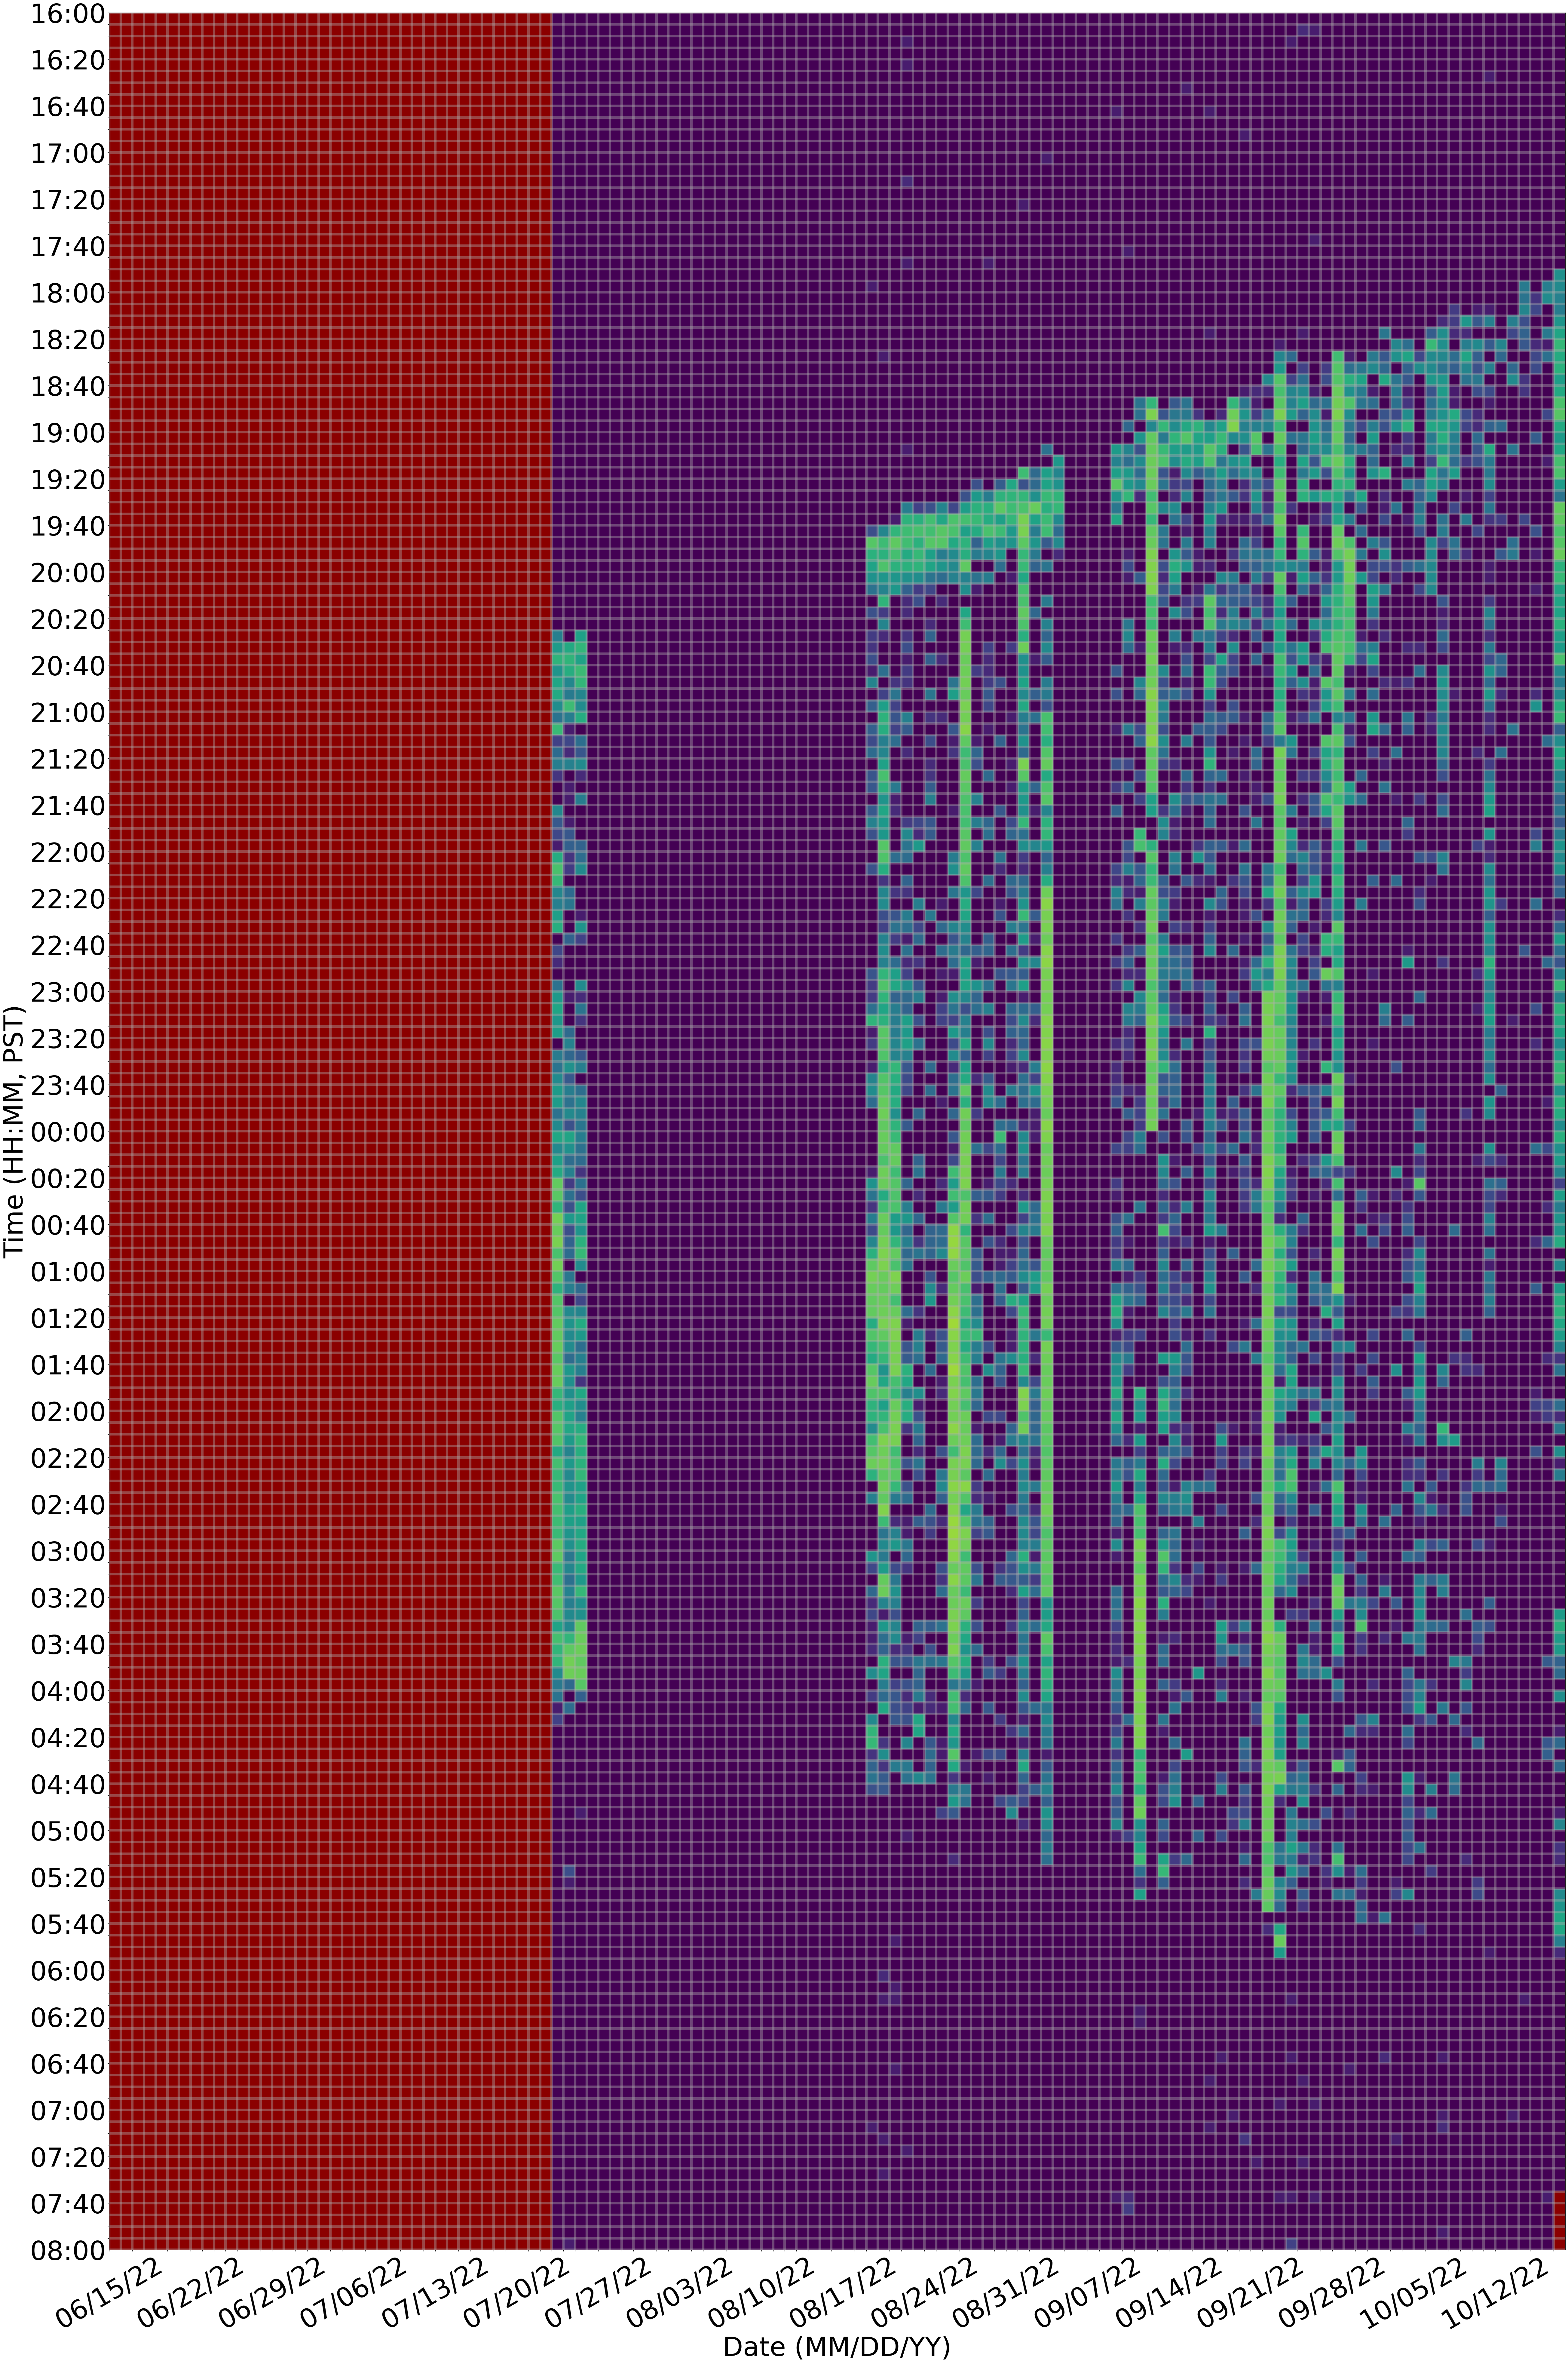

In [43]:
plt.rcParams.update({'font.size': (0.2*len(activity_dates) + 0.2*len(activity_times))})
fig, (ax1) = plt.subplots(1, 1, figsize=(0.5*len(activity_dates), 0.6*len(activity_times)), sharex=True, sharey=True)

masked_array_for_nodets = np.ma.masked_where(activity_df4.values==np.NaN, activity_df4.values)
im1 = ax1.imshow(1+(masked_array_for_nodets), cmap=cmap, norm=norm)
ax1.grid(which='both', linewidth=6, alpha=0.4)
ax1.set_ylabel(f'Time (HH:MM, {ylabel})')
ax1.set_xlabel('Date (MM/DD/YY)')
ax1.set_yticks(np.arange(0, len(plot_times))-0.5)
ax1.set_yticklabels(plot_times, ha='right')
ax1.set_xticks(np.arange(0, len(activity_df1.columns))-0.5)
ax1.set_xticklabels(plot_dates, rotation=30)

plt.show()